In [10]:
from uphate.nn import TransformerConfig, Transformer
from phate import PHATE
from phate.tree import gen_dla
from flax import nnx
import jax
import jax.numpy as jnp
import orbax.checkpoint as ocp

import matplotlib.pyplot as plt

Calculating PHATE...
  Running PHATE on 800 observations and 50 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.08 seconds.
    Calculating affinities...
    Calculated affinities in 2.31 seconds.
  Calculated graph and diffusion operator in 2.43 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.69 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.80 seconds.
Calculated PHATE in 7.95 seconds.


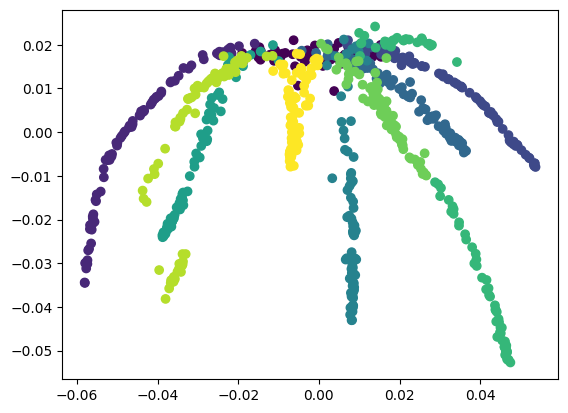

In [2]:
DATA_PARAMS = {
    "n_branch": 10,
    "n_dim": 50,
    "branch_length": 80,
}
X, labels = gen_dla(**DATA_PARAMS)
X -= X.mean(axis=0, keepdims=True)
X /= X.std(axis=0, keepdims=True)
X_phate = PHATE(knn=5, t=20, decay=15).fit_transform(X)
plt.scatter(*X_phate.T, c=labels)

In [32]:
abstract_model = nnx.eval_shape(
    lambda: Transformer(
        X.shape[1], X_phate.shape[1], rngs=nnx.Rngs(0), config=TransformerConfig()
    ),
)
graphdef, abstract_state = nnx.split(abstract_model)
state_restored = ocp.Checkpointer(ocp.StandardCheckpointHandler()).restore(
    "/home/cpsc4844_tl855/project_cpsc4844/cpsc4844_tl855/uPHATE/models/surrogate_dla_11122025_113201.nnx",
    item=jax.tree.map(
        lambda x: jnp.zeros(x.shape), abstract_state
    ),
)
model = nnx.merge(graphdef, state_restored)

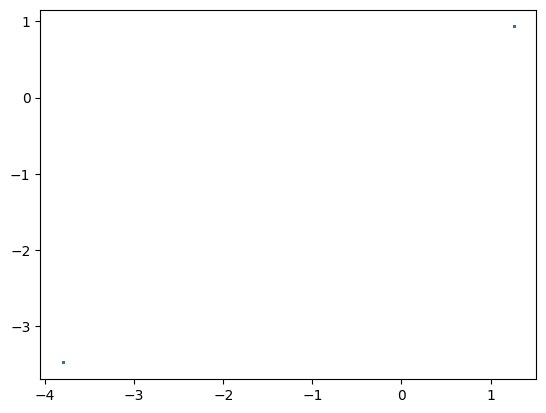

In [41]:
plt.scatter(*model(X).T, s=0.1)

In [12]:
config = TransformerConfig()
rngs = nnx.Rngs(0)
model = Transformer(X.shape[1], X_phate.shape[1], rngs=rngs, config=config)

In [13]:
model(jnp.array(X))

Array([[-0.577087  ,  0.67687327],
       [-0.57708734,  0.67687285],
       [-0.5770872 ,  0.6768732 ],
       ...,
       [-0.57708776,  0.67687285],
       [-0.57708716,  0.67687285],
       [-0.57708704,  0.6768733 ]], dtype=float32)